In [1]:
# === IMPORTS ===
import warnings
warnings.filterwarnings('ignore')

import wandb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from scipy import stats
from pathlib import Path

from figure_style import (
    setup_style, 
    COLORS, 
    get_layer_colors, 
    plot_with_band, 
    despine,
    save_figure,
    smooth
)
from mapping import EXPERIMENT_MANIFEST

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

# Setup style
USE_LATEX = False
setup_style(use_latex=USE_LATEX)

FIGURES_DIR = Path('./figures')
FIGURES_DIR.mkdir(exist_ok=True)

%load_ext autoreload
%autoreload 2

✓ Mathtext mode (no LaTeX required)


In [ ]:
# === CONFIG ===
ENTITY = "cyhsm"
PROJECT = "loom"

# Filter to loop3+ runs (exclude baseline and loop1)
RUNS = [r for r in EXPERIMENT_MANIFEST # also remove if cyclical in name
        if not r['name'].startswith('baseline') and not r['name'].startswith('loop1') and not 'cyclical' in r['name'] and not 'iso' in r['name']]

print(f"Runs to load: {len(RUNS)}")
for r in RUNS:
    print(f"  {r['name']}")

Runs to load: 13
  loop3_buckets_mvd
  loop3_iso_mvd
  loop3_L1024G512_ponder001
  loop3_L1024G512_ponder-001
  loop3_L1024G512_individualMemory_frozenmem
  loop3_L1024G512_individualMemory_init0
  loop3_L1024G512_individualMemory_init3
  loop3_L1024G512_individualMemory_init-3
  loop5_L1024G512
  loop5_buckets_mvd
  loop5_iso_mvd
  loop7_buckets_mvd
  loop9_buckets


In [3]:
# === LOAD DATA ===
api = wandb.Api(timeout=120)

all_data = {}
for run_info in RUNS:
    try:
        run = api.run(f"{ENTITY}/{PROJECT}/{run_info['run_id']}")
        print(f"Loading {run_info['name']}...")
        df = run.history(samples=100000, pandas=True)
        if 'train progress/consumed_tokens' in df.columns:
            df['tokens'] = df['train progress/consumed_tokens']
        all_data[run_info['name']] = df
    except Exception as e:
        print(f"  Failed: {e}")

print(f"\nLoaded {len(all_data)} runs")

Loading loop3_buckets_mvd...
Loading loop3_iso_mvd...
Loading loop3_L1024G512_ponder001...
Loading loop3_L1024G512_ponder-001...
Loading loop3_L1024G512_individualMemory_frozenmem...
Loading loop3_L1024G512_individualMemory_init0...
Loading loop3_L1024G512_individualMemory_init3...
Loading loop3_L1024G512_individualMemory_init-3...
Loading loop5_L1024G512...
Loading loop5_buckets_mvd...
Loading loop5_iso_mvd...
Loading loop7_buckets_mvd...
Loading loop9_buckets...

Loaded 13 runs


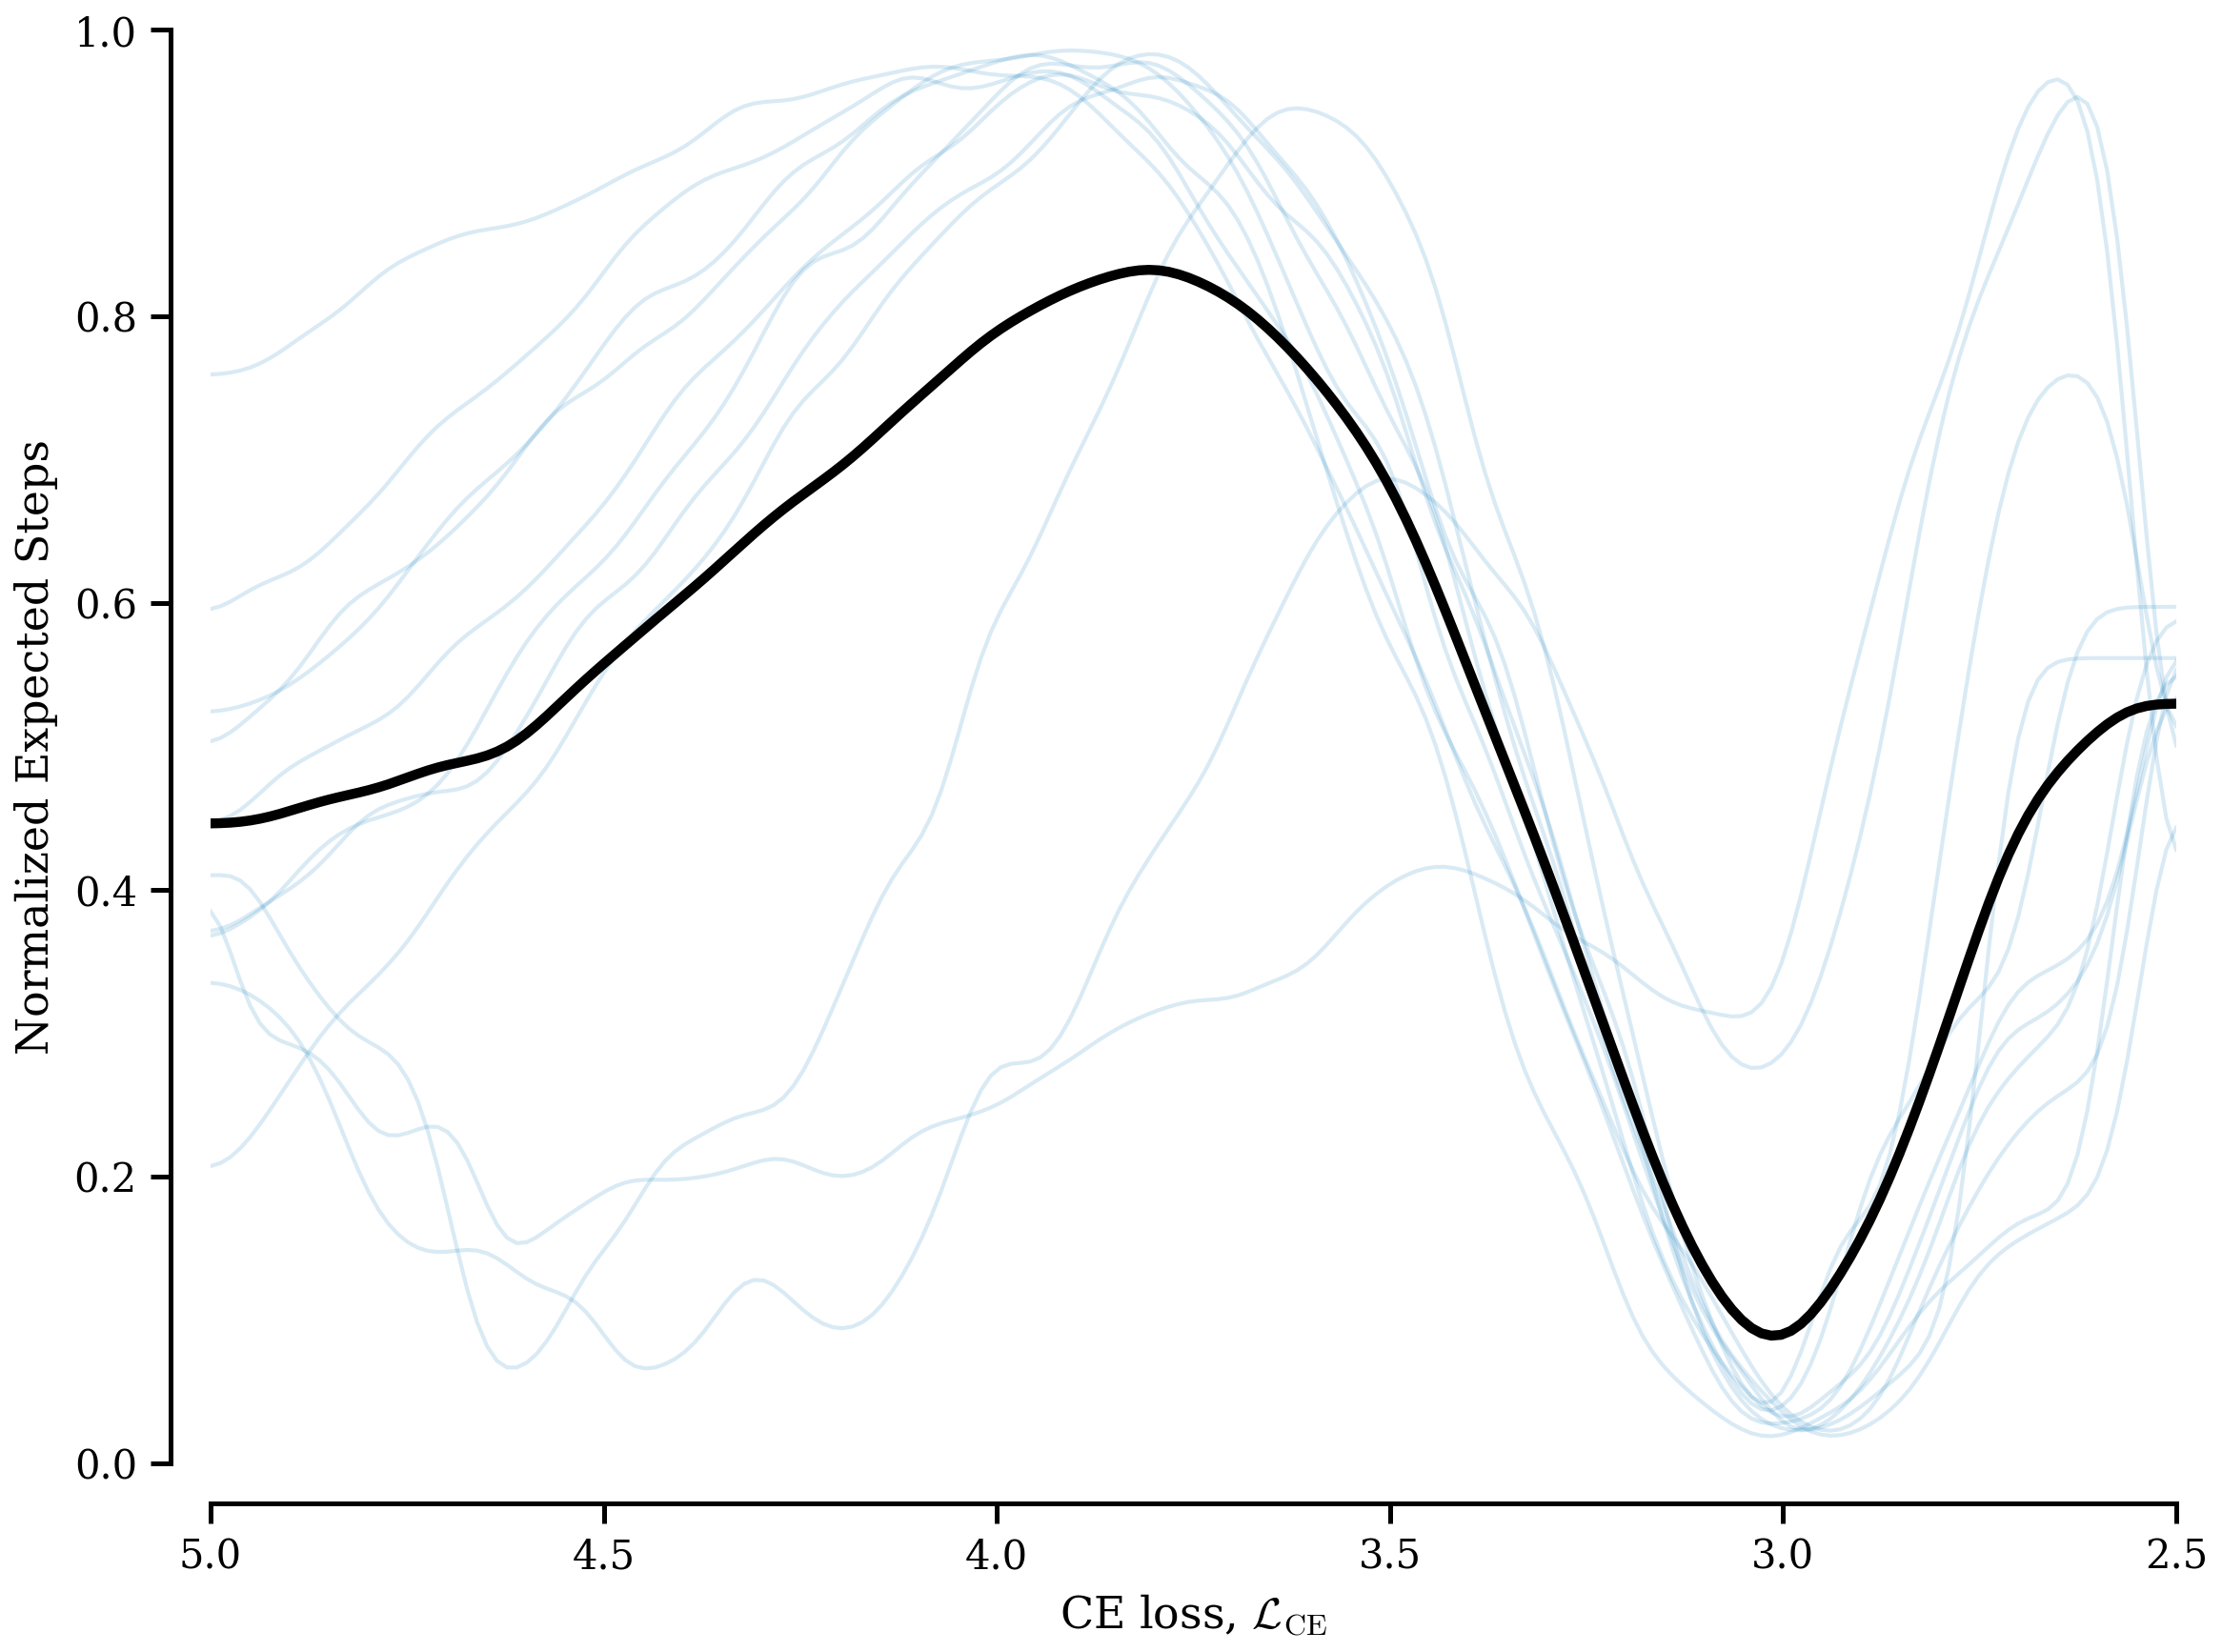

In [20]:
from scipy.interpolate import interp1d
from scipy.ndimage import gaussian_filter1d

common_ce = np.linspace(2.5, 5.0, 200)
all_interp = []

fig, ax = plt.subplots(figsize=(8, 6))

for name, df in all_data.items():
    ce = df['train loss/ce_avg'].values
    steps = df['train adaptive/expected_steps_avg'].values
    mask = ~np.isnan(ce) & ~np.isnan(steps)
    
    # Sort and interpolate
    order = np.argsort(ce[mask])
    f = interp1d(ce[mask][order], steps[mask][order], bounds_error=False, fill_value=np.nan)
    y = f(common_ce)
    
    # Normalize 0-1
    y = (y - np.nanmin(y)) / (np.nanmax(y) - np.nanmin(y))
    
    # Smooth and plot
    y = gaussian_filter1d(np.nan_to_num(y, nan=np.nanmean(y)), sigma=3)
    ax.plot(common_ce, y, alpha=0.15, lw=1, c=COLORS['blue'])
    all_interp.append(y)

# Average
avg = gaussian_filter1d(np.nanmean(all_interp, axis=0), sigma=2)
ax.plot(common_ce, avg, color='black', lw=2.5, label='Average')

ax.set_xlim([5, 2.5])
ax.set_ylim([0, 1])
ax.set_xlabel(r'CE loss, $\mathcal{L}_{\mathrm{CE}}$')
ax.set_ylabel(r'Normalized Expected Steps')
despine(ax)
plt.tight_layout()
plt.show()

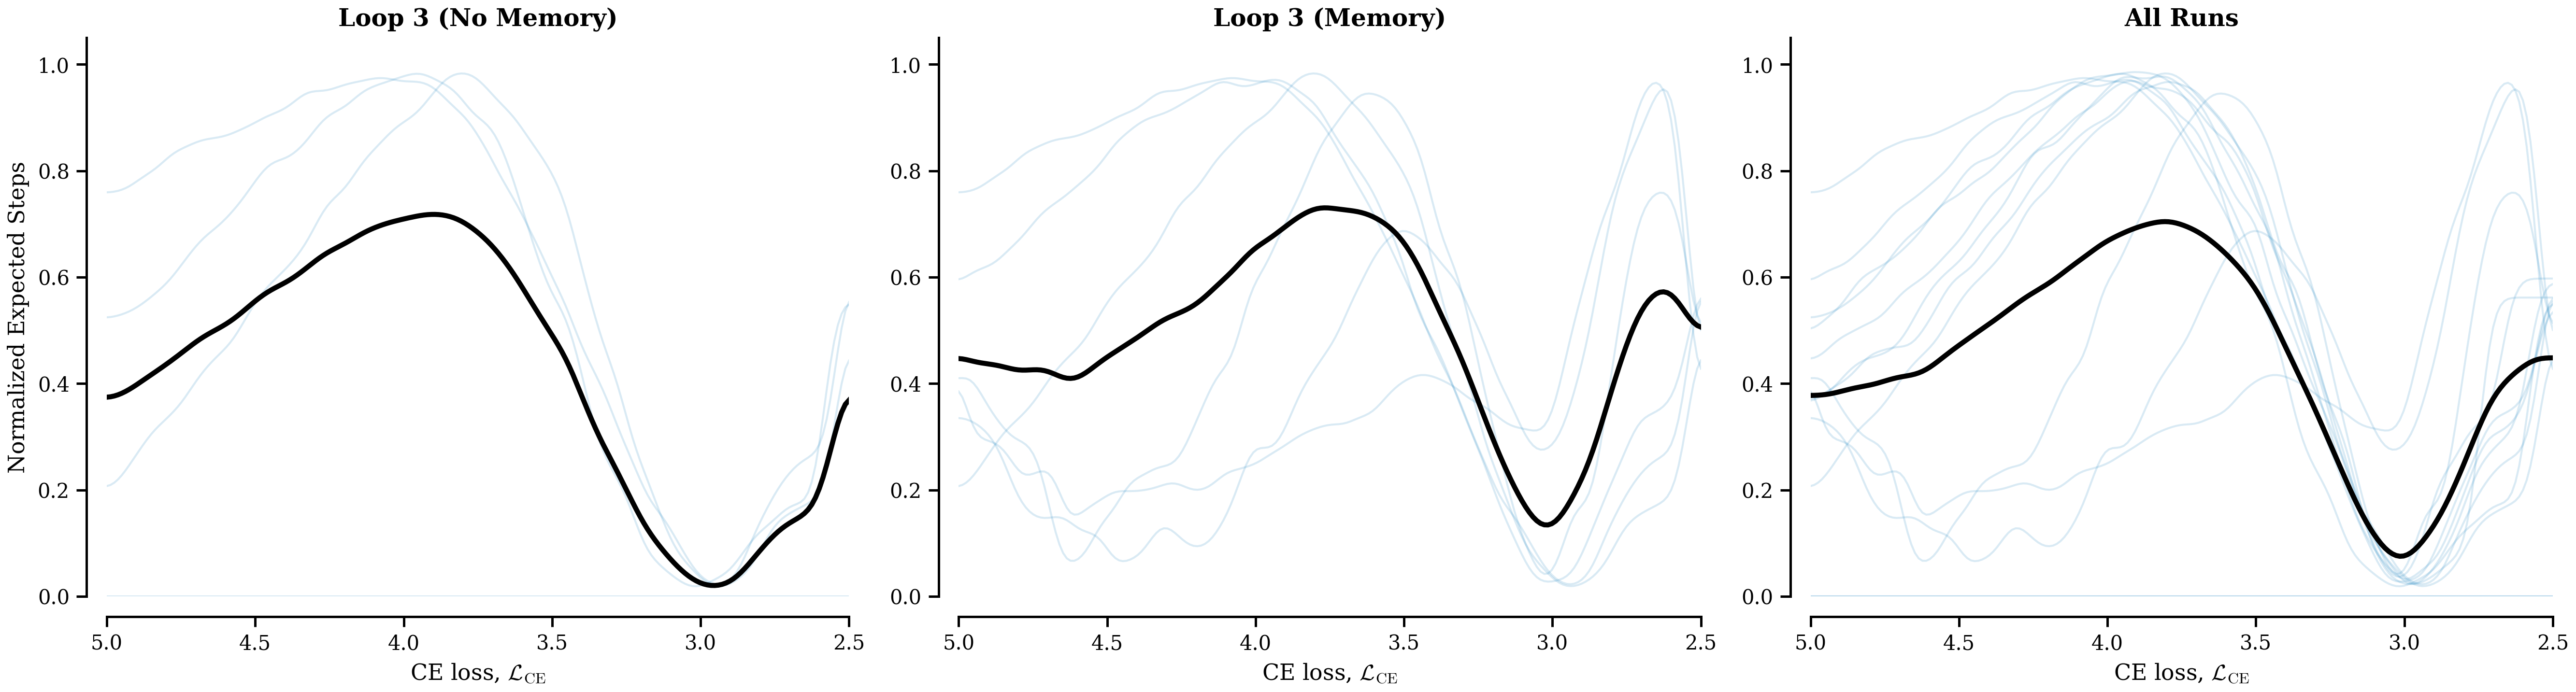

In [24]:
from scipy.interpolate import interp1d
from scipy.ndimage import gaussian_filter1d

# === 1. DEFINE GROUPS ===
available_runs = list(all_data.keys())

# Group 1: Loop 3 (No Memory)
group_l3_no_mem = [
    r for r in available_runs 
    if r.startswith('loop3') and 'individualMemory' not in r
]

# Group 2: Loop 3 (With Memory)
group_l3_mem = [
    r for r in available_runs 
    if r.startswith('loop3') and 'L1024G512' in r
]

# Group 3: All Runs
group_all = available_runs

groups = [
    ("Loop 3 (No Memory)", group_l3_no_mem),
    ("Loop 3 (Memory)", group_l3_mem),
    ("All Runs", group_all)
]

# === 2. PLOTTING FUNCTION ===
def plot_metric_vs_loss(ax, run_names, data_dict, title, show_ylabel=False):
    common_ce = np.linspace(2.5, 5.0, 200)
    group_interp = []

    for name in run_names:
        if name not in data_dict: continue
            
        df = data_dict[name]
        ce = df['train loss/ce_avg'].values
        steps = df['train adaptive/expected_steps_avg'].values
        
        mask = ~np.isnan(ce) & ~np.isnan(steps)
        if mask.sum() < 2: continue 
        
        # Sort and Interpolate
        order = np.argsort(ce[mask])
        f = interp1d(ce[mask][order], steps[mask][order], bounds_error=False, fill_value=np.nan)
        y = f(common_ce)
        
        # Normalize (0-1)
        if np.nanmax(y) != np.nanmin(y):
            y = (y - np.nanmin(y)) / (np.nanmax(y) - np.nanmin(y))
        
        # Smooth
        y = gaussian_filter1d(np.nan_to_num(y, nan=np.nanmean(y)), sigma=3)
        
        ax.plot(common_ce, y, alpha=0.15, lw=1, c=COLORS['blue'])
        group_interp.append(y)

    # Average
    if group_interp:
        avg = gaussian_filter1d(np.nanmean(group_interp, axis=0), sigma=2)
        ax.plot(common_ce, avg, color='black', lw=2.5, label='Average')

    # Formatting
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlim([5, 2.5])
    ax.set_ylim([0, 1.05])
    ax.set_xlabel(r'CE loss, $\mathcal{L}_{\mathrm{CE}}$')
    
    # Only show Y label if requested
    if show_ylabel:
        ax.set_ylabel(r'Normalized Expected Steps')
    
    despine(ax)

# === 3. EXECUTE PLOT ===
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

# Enumerate to determine index
for i, (ax, (title, run_list)) in enumerate(zip(axes, groups)):
    plot_metric_vs_loss(ax, run_list, all_data, title, show_ylabel=(i == 0))

plt.tight_layout()
plt.show()